In [4]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
dataset_root = r"E:/Studies/Self/CCTV-Threat-Detection/Data/Smart-City-CCTV-Violence-Detection-Dataset (SCVD)/SCVD_converted"
train_dir = os.path.join(dataset_root, "Train")
test_dir = os.path.join(dataset_root, "Test")

classes = ["Normal", "Violence", "Weaponized"]
print("Classes:", classes)

Classes: ['Normal', 'Violence', 'Weaponized']


In [6]:
class VideoDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None, frames_per_clip=16):
        self.samples = []
        self.transform = transform
        self.frames_per_clip = frames_per_clip
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        for cls in classes:
            class_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(class_dir):
                if fname.endswith(".avi"):
                    self.samples.append((os.path.join(class_dir, fname), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        cap = cv2.VideoCapture(video_path)
        frames = []
        while len(frames) < self.frames_per_clip and cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)
        cap.release()

        # Pad if fewer frames
        while len(frames) < self.frames_per_clip:
            frames.append(torch.zeros_like(frames[0]))

        video_tensor = torch.stack(frames)  # shape: (T, C, H, W)
        # Rearrange to (C, T, H, W) for I3D input
        video_tensor = video_tensor.permute(1, 0, 2, 3)
        return video_tensor, label

In [ ]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.45, 0.45, 0.45],
                         std=[0.225, 0.225, 0.225])
])

train_dataset = VideoDataset(train_dir, classes, transform, frames_per_clip=16)
test_dataset = VideoDataset(test_dir, classes, transform, frames_per_clip=16)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 399
Test samples: 82


In [8]:
#Load pretrained I3D (ResNet3D-50) from TorchHub
model = torch.hub.load('facebookresearch/pytorchvideo', 'i3d_r50', pretrained=True)

#Replace classifier head for SCVD (3 classes)
model.blocks[-1].proj = nn.Linear(model.blocks[-1].proj.in_features, len(classes))

#Freeze backbone, train only classifier head
for param in model.parameters():
    param.requires_grad = False
for param in model.blocks[-1].proj.parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Downloading: "https://github.com/facebookresearch/pytorchvideo/zipball/main" to C:\Users\risha/.cache\torch\hub\main.zip
Downloading: "https://dl.fbaipublicfiles.com/pytorchvideo/model_zoo/kinetics/I3D_8x8_R50.pyth" to C:\Users\risha/.cache\torch\hub\checkpoints\I3D_8x8_R50.pyth


100%|██████████| 214M/214M [00:17<00:00, 12.6MB/s] 


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.blocks[-1].proj.parameters(), lr=1e-4)

In [10]:
epochs = 20
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for videos, labels in train_loader:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/20, Loss: 1.0583
Epoch 2/20, Loss: 1.0323
Epoch 3/20, Loss: 1.0274
Epoch 4/20, Loss: 0.9955
Epoch 5/20, Loss: 0.9930
Epoch 6/20, Loss: 0.9714
Epoch 7/20, Loss: 0.9604
Epoch 8/20, Loss: 0.9430
Epoch 9/20, Loss: 0.9360
Epoch 10/20, Loss: 0.9283
Epoch 11/20, Loss: 0.9149
Epoch 12/20, Loss: 0.9044
Epoch 13/20, Loss: 0.8888
Epoch 14/20, Loss: 0.8997
Epoch 15/20, Loss: 0.8692
Epoch 16/20, Loss: 0.8668
Epoch 17/20, Loss: 0.8602
Epoch 18/20, Loss: 0.8535
Epoch 19/20, Loss: 0.8700
Epoch 20/20, Loss: 0.8540


              precision    recall  f1-score   support

      Normal       0.79      0.96      0.86        46
    Violence       0.30      0.25      0.27        12
  Weaponized       0.44      0.29      0.35        24

    accuracy                           0.66        82
   macro avg       0.51      0.50      0.50        82
weighted avg       0.61      0.66      0.63        82



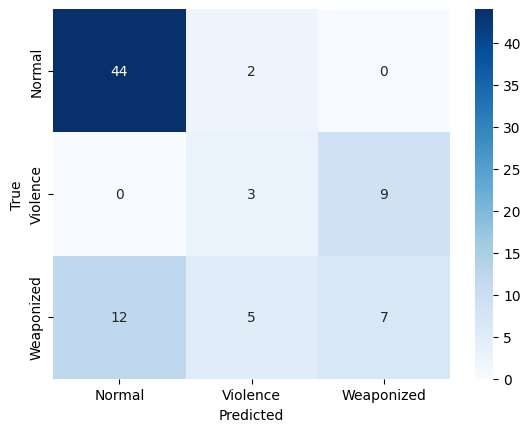

In [11]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for videos, labels in test_loader:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
